# 06. Light tuning and calibration

**Objective.** Check whether hyperparameter tuning improves the chosen gradient-boosting model, and whether its probabilities need calibration.

**Business question.** Can we trust a predicted 12% to mean about 12 in 100 such applicants, so that it can feed expected-loss and pricing calculations?

**Why this analysis is needed.** Notebook 05 showed the average prediction is right. A lender needs the probability to be right across the whole range, not only on average.

Everything uses the training split for fitting and the validation split for scoring. The test split is untouched.

*Educational project. Not a lending policy.*

## Experiment 1: a small tuning grid

Eight settings, chosen to probe the main levers (learning rate, tree size, leaf size, regularisation, depth). This is deliberately small: the earlier phases suggest the data limits performance more than the settings do.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from src.data import load_modelling_table
from src.plots import apply_style
from src.train import *

warnings.filterwarnings("ignore")
apply_style()
table = load_modelling_table()
columns = feature_columns(table, ratios=True, history=True, drop=SOCIAL_CIRCLE)
grid = {
    "defaults": {},
    "lr 0.03, 800 iter": dict(learning_rate=0.03, max_iter=800),
    "15 leaves": dict(max_leaf_nodes=15),
    "63 leaves": dict(max_leaf_nodes=63),
    "min leaf 300": dict(min_samples_leaf=300),
    "l2 = 10": dict(l2_regularization=10.0),
    "15 leaves, min leaf 300, lr 0.03": dict(max_leaf_nodes=15, min_samples_leaf=300, learning_rate=0.03, max_iter=800),
    "depth 4, lr 0.05": dict(max_depth=4, learning_rate=0.05),
}
rows = {}
for name, settings in grid.items():
    model = make_boosting(table, columns, **settings)
    scores, _ = fit_and_score(model, table, columns)
    scores["trees"] = model.named_steps["model"].n_iter_
    rows[name] = scores
tuning = pd.DataFrame(rows).T[["roc_auc", "pr_auc", "ks", "brier", "trees"]]
print(tuning.round(4).to_string())

                                  roc_auc  pr_auc      ks   brier  trees
defaults                           0.7691  0.2501  0.4039  0.0674  247.0
lr 0.03, 800 iter                  0.7695  0.2515  0.4080  0.0673  465.0
15 leaves                          0.7688  0.2494  0.4075  0.0674  345.0
63 leaves                          0.7664  0.2472  0.4028  0.0676  240.0
min leaf 300                       0.7695  0.2491  0.4047  0.0675  344.0
l2 = 10                            0.7695  0.2507  0.4071  0.0674  336.0
15 leaves, min leaf 300, lr 0.03   0.7696  0.2508  0.4056  0.0674  658.0
depth 4, lr 0.05                   0.7705  0.2500  0.4073  0.0674  500.0


**Result.** ROC-AUC ranges from 0.7664 (63 leaves) to 0.7705 (depth 4, learning rate 0.05). Defaults give 0.7691. Six of eight settings are within 0.0005 of the defaults.

**Interpretation.** The best setting beats the defaults by 0.0014, and I looked at eight settings, so picking the maximum flatters it. The bootstrap noise for a single AUC is about 0.004. Bigger trees (63 leaves) are worse, which means the model already has enough capacity; the limit is the information in the data.

**Decision.** Use depth 4 with learning rate 0.05. It is the simplest, shallowest model among the top results, so if the gain is partly luck, nothing is lost. Its 500 trees hit the 500-iteration cap (early stopping did not trigger), so part of its edge may just be more trees at a smaller learning rate; the notebook does not separate the two. Do not tune further: more search would fit the validation split. See D26.

## Experiment 2: are the probabilities calibrated?

Ten equal-size groups by predicted probability. In a calibrated model the average prediction and the actual default rate match in every group.

       predicted  actual  applicants
group                               
1         0.0111  0.0109        6151
2         0.0193  0.0176        6150
3         0.0266  0.0239        6150
4         0.0347  0.0324        6150
5         0.0446  0.0454        6150
6         0.0574  0.0593        6150
7         0.0749  0.0751        6150
8         0.1019  0.1117        6150
9         0.1495  0.1504        6150
10        0.2909  0.2806        6151


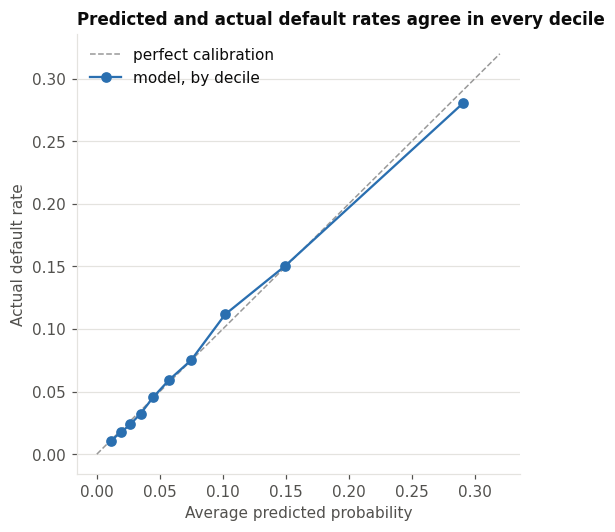

In [2]:
model = make_boosting(table, columns, max_depth=4, learning_rate=0.05)
scores, probabilities = fit_and_score(model, table, columns)
y = table[table["split"] == "valid"][config.TARGET].to_numpy()
frame = pd.DataFrame({"y": y, "p": probabilities})
frame["group"] = pd.qcut(frame["p"], 10, labels=False) + 1
reliability = frame.groupby("group").agg(predicted=("p", "mean"), actual=("y", "mean"), applicants=("y", "size"))
print(reliability.round(4).to_string())

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot([0, 0.32], [0, 0.32], color="#999999", linestyle="--", linewidth=1, label="perfect calibration")
ax.plot(reliability["predicted"], reliability["actual"], marker="o", color="#2a6fb0", label="model, by decile")
ax.set_xlabel("Average predicted probability")
ax.set_ylabel("Actual default rate")
ax.set_title("Predicted and actual default rates agree in every decile", loc="left")
ax.legend(frameon=False)
plt.show()

**Result.** The predicted and actual rates agree closely from the lowest decile (1.11% predicted, 1.09% actual) to the highest (29.1% predicted, 28.1% actual). The largest gap is in decile 8: 10.2% predicted against 11.2% actual, on 6,150 applicants, which is about one standard error (roughly 0.4 points).

## Experiment 3: would a calibrator help?

A calibrator is fitted on half of the validation set and compared with the raw model on the other half. Isotonic regression and Platt scaling (logistic regression on the log-odds) are both tried.

In [3]:
first, second = train_test_split(np.arange(len(y)), test_size=0.5, stratify=y, random_state=config.RANDOM_SEED)
def log_odds(q):
    q = np.clip(q, 1e-6, 1 - 1e-6)
    return np.log(q / (1 - q)).reshape(-1, 1)
isotonic = IsotonicRegression(out_of_bounds="clip").fit(probabilities[first], y[first])
platt = LogisticRegression(C=1e6).fit(log_odds(probabilities[first]), y[first])
candidates = {
    "raw": probabilities[second],
    "isotonic": isotonic.predict(probabilities[second]),
    "platt": platt.predict_proba(log_odds(probabilities[second]))[:, 1],
}
comparison = pd.DataFrame(
    {name: {"brier": brier_score_loss(y[second], q), "log_loss": log_loss(y[second], np.clip(q, 1e-6, 1 - 1e-6))} for name, q in candidates.items()}
).T
print(comparison.round(5).to_string())
print("Platt slope on log-odds:", round(float(platt.coef_[0][0]), 3), " intercept:", round(float(platt.intercept_[0]), 3))

            brier  log_loss
raw       0.06760   0.24426
isotonic  0.06756   0.24439
platt     0.06759   0.24425
Platt slope on log-odds: 0.994  intercept: -0.018


**Result.** Brier on the held-out half: raw 0.06760, isotonic 0.06756, Platt 0.06759. Log-loss: raw 0.24426, isotonic 0.24439, Platt 0.24425. The Platt slope is 0.994 and the intercept -0.018; a perfectly calibrated model has slope 1 and intercept 0.

**Interpretation.** Neither calibrator improves anything beyond the fourth decimal, and isotonic slightly worsens log-loss. The model was already calibrated. That is expected: it is trained with log-loss on the natural default rate, and there was no reweighting (D20). Calibration would matter had we used class weights.

**Decision.** No calibrator. Use the raw model probabilities as the probability of default (PD). Fitting a calibrator anyway would add a component to explain and no accuracy. See D27.

## Next step

Notebook 07: the final model on the test split (opened once), and the threshold and cost analysis.